# Analisis de uso de la plataforma por parte de los usuarios.

---

## Objetivo:

En este notebook analizamos el comportamiento de uso de la plataforma 
a partir de las sesiones registradas por los usuarios. 
El objetivo es comprender su nivel de actividad, identificar patrones de uso 
y comparar el comportamiento entre distintos tipos de usuarios.

* Número de sesiones por usuario.
* Nivel de actividad de los usuarios.
* Diferencias entre segmentos de usuarios.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
plt.style.use("default")


## Carga de datasets.

Se cargan los datasets necesarios para analizar el comportamiento de uso de la plataforma. En este notebook trabajaremos principalmente con la información de usuarios y sesiones.


In [3]:
users = pd.read_csv("../data/raw/users.csv")
sessions = pd.read_csv("../data/raw/sessions.csv")


### Exploración inicial del dataset de sesiones

In [4]:
sessions.head()

,session_id,user_id,session_start,duration_sec,pages_viewed,device,traffic_source,primary_action
0,1,30602,2024-04-04 13:53:00,103.0,5.0,desktop,paid_search,add_to_cart
1,2,9439,2024-10-07 00:37:00,379.0,4.0,desktop,organic,add_to_cart
2,3,23658,2024-10-18 13:33:00,222.0,3.0,mobile,paid_social,checkout
3,4,3423,2025-04-15 16:53:00,246.0,7.0,mobile,referral,search
4,5,24425,2024-04-11 03:35:00,924.0,4.0,mobile,organic,add_to_cart


### Sesiones por usuario

Calculamos el número de sesiones realizadas por cada usuario para conocer su nivel de actividad dentro de la plataforma.

In [5]:
sessions_per_user = sessions.groupby("user_id").size().reset_index(name="num_sessions")
sessions_per_user.head()

,user_id,num_sessions
0,8,105
1,9,2
2,11,2
3,18,2
4,22,3


### Analisis de la distribucion

Antes de representar gráficamente los datos, revisamos las estadísticas descriptivas para comprender cómo se distribuye el número de sesiones por usuario e identificar posibles valores extremos.

Se observan varios usuarios con un número de sesiones significativamente superior al resto, lo que provoca una fuerte distorsión en la escala del histograma. Dado que se trata de un dataset sintético utilizado con fines de práctica, estos valores se consideran extremos y se excluyen únicamente de la visualización para facilitar la interpretación de la distribución general.

In [6]:
sessions_per_user["num_sessions"].describe()

count     6977.000000
mean        45.864985
std       1118.467421
min          1.000000
25%          1.000000
50%          1.000000
75%          3.000000
max      70239.000000
Name: num_sessions, dtype: float64

## Detección de valores extremos

Las estadísticas descriptivas muestran la existencia de usuarios con un número de sesiones muy superior al comportamiento habitual. Revisamos los usuarios con mayor actividad para confirmar la presencia de estos valores extremos.

In [7]:
sessions_per_user.sort_values(
    by="num_sessions",
    ascending=False
).head(10)

,user_id,num_sessions
1349,9439,70239
3459,24425,46395
383,2632,18793
955,6441,18491
498,3423,17996
3357,23658,13794
6733,48236,12686
3809,26846,8116
3892,27457,6402
672,4563,5368


### Distribución del número de sesiones.

La mayoría de los usuarios concentra su actividad en un número reducido de sesiones. Para facilitar la interpretación, representamos el número de usuarios según sus sesiones registradas, centrándonos en los valores más habituales.

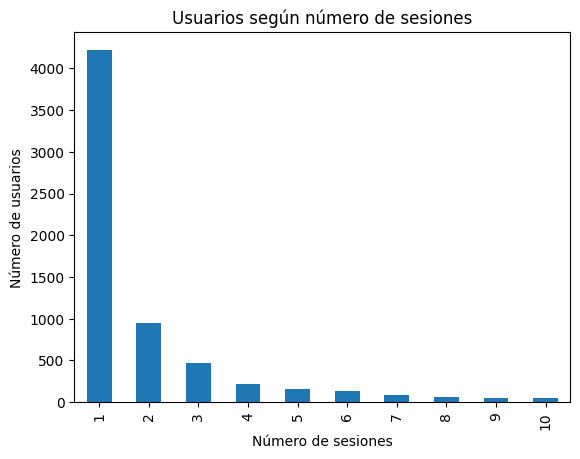

In [8]:
sessions_frequency = (
    sessions_per_user[sessions_per_user["num_sessions"] <= 10]
    ["num_sessions"]
    .value_counts()
    .sort_index()
)

sessions_frequency.plot(kind="bar")

plt.title("Usuarios según número de sesiones")
plt.xlabel("Número de sesiones")
plt.ylabel("Número de usuarios")
plt.show()

Unimos información de sesiones con datos del usuario para poder analizar comportamiento por tipo de usuario.

In [9]:
sessions_users = sessions.merge(users, on="user_id", how="left")
sessions_users.head()


,session_id,user_id,session_start,duration_sec,pages_viewed,device,traffic_source,primary_action,signup_date,country,acquisition_channel,utm_campaign,first_device,gender,age,plan,marketing_opt_in,is_churned,churn_date
0,1,30602,2024-04-04 13:53:00,103.0,5.0,desktop,paid_search,add_to_cart,2024-03-28,FR,paid_search,brand,desktop,non_binary,18,free,True,True,2024-08-14
1,2,9439,2024-10-07 00:37:00,379.0,4.0,desktop,organic,add_to_cart,2024-09-04,IT,organic,brand,desktop,male,49,free,True,True,2024-11-24
2,3,23658,2024-10-18 13:33:00,222.0,3.0,mobile,paid_social,checkout,2024-06-25,US,paid_social,retargeting,mobile,male,26,basic,True,True,2024-11-14
3,4,3423,2025-04-15 16:53:00,246.0,7.0,mobile,referral,search,2025-03-05,DE,referral,brand,mobile,male,61,free,True,False,NaN
4,5,24425,2024-04-11 03:35:00,924.0,4.0,mobile,organic,add_to_cart,2024-02-14,CO,organic,NaN,mobile,female,31,free,False,True,2024-04-12


### Comparacion de sesiones segun el plan.

Comparamos el número de sesiones registradas en cada plan para conocer qué tipos de usuario concentran mayor volumen de actividad en la plataforma.

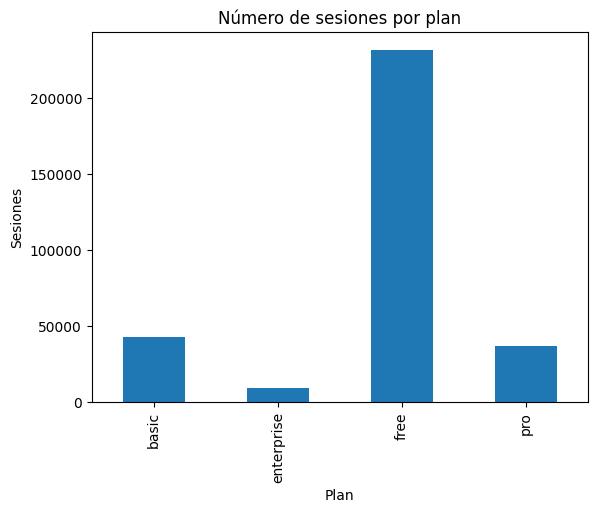

In [ ]:
sessions_by_plan = sessions_users.groupby("plan")["session_id"].count()

sessions_by_plan.plot(kind="bar")
plt.title("Número de sesiones por plan")
plt.xlabel("Plan")
plt.ylabel("Sesiones")
plt.show()


### Duración de las sesiones

Analizamos la duración de las sesiones para conocer cuánto tiempo permanecen los usuarios en la plataforma.


In [11]:
sessions["duration_sec"].describe()

count    319026.000000
mean        301.503185
std         219.158901
min          15.000000
25%         157.000000
50%         244.000000
75%         378.000000
max        5206.000000
Name: duration_sec, dtype: float64

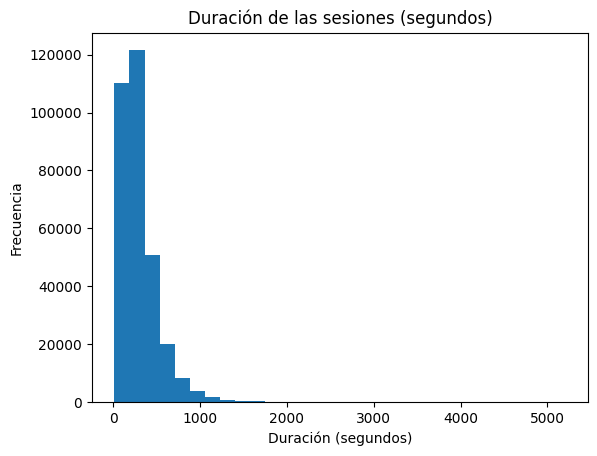

In [12]:
sessions["duration_sec"].plot(kind="hist", bins=30)
plt.title("Duración de las sesiones (segundos)")
plt.xlabel("Duración (segundos)")
plt.ylabel("Frecuencia")
plt.show()

### Analisis de actividad diaria en la plataforma.

Analizamos cómo se distribuyen las sesiones a lo largo del tiempo para identificar posibles cambios en el nivel de actividad de la plataforma.


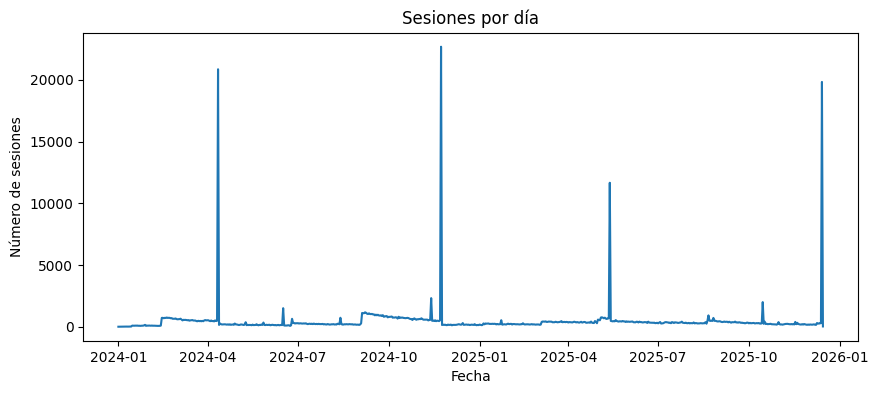

In [13]:
sessions["session_start"] = pd.to_datetime(sessions["session_start"])

sessions_per_day = sessions.groupby(sessions["session_start"].dt.date).size()

sessions_per_day.plot(figsize=(10,4))
plt.title("Sesiones por día")
plt.xlabel("Fecha")
plt.ylabel("Número de sesiones")
plt.show()


### Conclusiones

A partir del análisis de las sesiones podemos destacar:

* La actividad está muy concentrada: la mayoría de usuarios registra pocas sesiones, mientras que existe un grupo reducido con una actividad mucho mayor.
* El plan free concentra el mayor número de sesiones, aunque esto también está relacionado con que es el plan con más usuarios.
* Las sesiones tienen duraciones bastante diferentes, con la mayoría concentrada en duraciones relativamente cortas.
* La actividad de la plataforma varía a lo largo del tiempo y se observan algunos picos puntuales de sesiones.
